### APIs and Data Collection

APIs specifically REST APIs allow our programs to communicate through the internet hence we can obtain and 
process data rom multiple sources and storage sources.

HTTP methods are a way of transmitting the data over the internet.

In [1]:
from pycoingecko import CoinGeckoAPI
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from nba_api.stats.static import teams
from nba_api.stats.endpoints import leaguegamefinder
import seaborn as sns
import requests
import numpy as np

In [3]:
import requests

filename = "https://s3-api.us-geo.objectstorage.softlayer.net/cf-courses-data/CognitiveClass/PY0101EN/Chapter%205/Labs/Golden_State.pkl"

def download(url, filename):
    response = requests.get(url)
    print(response.headers)
    response.json()
    if response.status_code == 200:
        with open(filename, "wb") as f:
            f.write(response.content)

#download(filename, "data/Golden_State.pkl")

In [ ]:
games = pd.read_pickle("data/Golden_State.pkl")
games.head()

,SEASON_ID,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,PTS,...,FT_PCT,OREB,DREB,REB,AST,STL,BLK,TOV,PF,PLUS_MINUS
0,22019,1610612744,GSW,Golden State Warriors,1521900066,2019-07-12,GSW vs. LAL,L,200,87,...,0.800,13.0,29.0,42.0,13,10.0,3,11.0,21,3.2
1,22019,1610612744,GSW,Golden State Warriors,1521900058,2019-07-10,GSW @ DEN,W,201,73,...,0.867,7.0,27.0,34.0,10,11.0,7,20.0,20,-8.0
2,22019,1610612744,GSW,Golden State Warriors,1521900039,2019-07-08,GSW @ LAL,W,200,88,...,0.621,8.0,29.0,37.0,21,10.0,4,13.0,22,8.0
3,22019,1610612744,GSW,Golden State Warriors,1521900020,2019-07-07,GSW vs. TOR,W,201,80,...,0.923,6.0,37.0,43.0,18,8.0,3,20.0,25,10.0
4,22019,1610612744,GSW,Golden State Warriors,1521900007,2019-07-05,GSW vs. CHA,L,200,85,...,0.889,8.0,28.0,36.0,19,9.0,3,13.0,15,-8.0


In [ ]:
games_away = games[games["MATCHUP"]=="GSW @ TOR"]
games_home =  games[games["MATCHUP"]=="GSW vs. TOR"]

In [ ]:
print(games_away["PLUS_MINUS"].mean())
print(games_home["PLUS_MINUS"].mean())

-0.6071428571428571
3.730769230769231


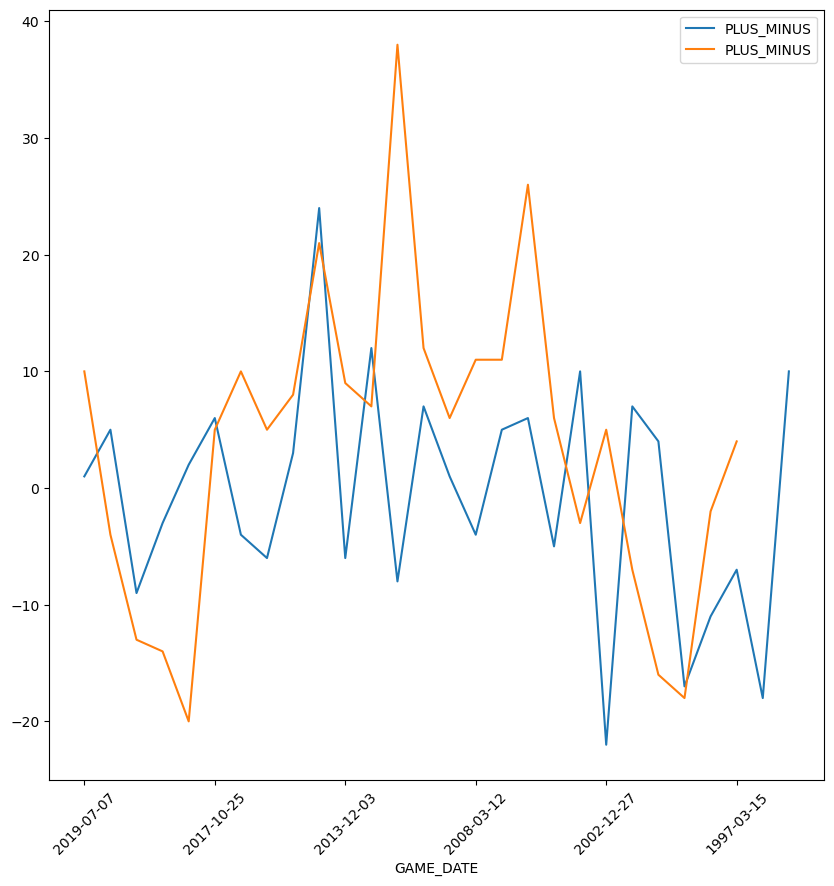

In [ ]:
fig, ax = plt.subplots(figsize = (10,10))
games_away.plot(x="GAME_DATE", y="PLUS_MINUS", ax=ax)
games_home.plot(x="GAME_DATE", y="PLUS_MINUS", ax=ax)
ax.tick_params(axis='x', labelrotation=45)

In [ ]:
cg = CoinGeckoAPI()
bitcoin_data = cg.get_coin_market_chart_by_id(id='bitcoin', vs_currency='usd', days =30)

In [ ]:
type(bitcoin_data)

dict

In [ ]:
bitcoin_data.keys()

dict_keys(['prices', 'market_caps', 'total_volumes'])

In [ ]:
data = pd.DataFrame(bitcoin_data['prices'], columns=["TimeStamp","Price"])

In [ ]:
data["Date"] = pd.to_datetime(data["TimeStamp"],unit='ms')

In [ ]:
candlestick_data = data.groupby(data.Date.dt.date).agg({"Price":["min","max","first","last"]})

In [ ]:
fig = go.Figure(data = [go.Candlestick(x=candlestick_data.index,
                                                   open=candlestick_data['Price']['first'],
                                                    high = candlestick_data['Price']['max'],
                                                    low = candlestick_data['Price']['min'],
                                                    close = candlestick_data['Price']['last']
                                                   )
                                    ])

fig.update_layout(xaxis_rangeslider_visible=False,
                  xaxis_title='Date', 
                  yaxis_title = 'Price (usd $)',
                  title = 'Bitcoin CandleStick Chart over the past 30 days'
                 )
fig.show()

## HTTP Methods and descriptions

These include: 

GET Retrieves data from the server

POST Submits data to the server

PUT Updates data already on the server

DELETE Deletes data from the server

In [ ]:
import os


url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0101EN-SkillsNetwork/labs/Module%205/data/Example1.txt"
req = requests.get(url)
path = "data/Example.txt"
with open(path,"wb") as file_name:
    file_name.write(req.content)

    

In [ ]:
url_get='https://httpbin.org/get'
params = {"name":"Joseph","ID":"123"}
rs = requests.get(url_get, params = params)


In [ ]:
print(rs.url)

https://httpbin.org/get?name=Joseph&ID=123


In [ ]:
print(rs.request.body) ## There is no request body, body is mostly in POST and UPDATE requests

None


In [ ]:
print(rs.headers["content-type"])

application/json


In [ ]:
rs.json()

{'args': {'ID': '123', 'name': 'Joseph'},
 'headers': {'Accept': '*/*',
  'Accept-Encoding': 'gzip, deflate, br, zstd',
  'Host': 'httpbin.org',
  'User-Agent': 'python-requests/2.32.5',
  'X-Amzn-Trace-Id': 'Root=1-6aa8a25b-7f2ab7b100469aa076c008e9'},
 'origin': '102.203.137.242',
 'url': 'https://httpbin.org/get?name=Joseph&ID=123'}

In [ ]:
rs.json()['args']

{'ID': '123', 'name': 'Joseph'}

### POST Requests

In [ ]:
url_post = 'https://httpbin.org/post'
payload = params
r_post = requests.post(url_post, data = payload)


In [ ]:
## Check how the URLs are:
print(rs.url)
print(r_post.url)

https://httpbin.org/get?name=Joseph&ID=123
https://httpbin.org/post


In [ ]:
## Check how different the request body are
print(rs.request.body)
print(r_post.request.body)

None
name=Joseph&ID=123


In [ ]:
r_post.json()

{'args': {},
 'data': '',
 'files': {},
 'form': {'ID': '123', 'name': 'Joseph'},
 'headers': {'Accept': '*/*',
  'Accept-Encoding': 'gzip, deflate, br, zstd',
  'Content-Length': '18',
  'Content-Type': 'application/x-www-form-urlencoded',
  'Host': 'httpbin.org',
  'User-Agent': 'python-requests/2.32.5',
  'X-Amzn-Trace-Id': 'Root=1-6aa7b0d0-5cddff99154f402f135a4607'},
 'json': None,
 'origin': '197.248.18.239',
 'url': 'https://httpbin.org/post'}

In [ ]:
print(r_post.json()['form'])

{'ID': '123', 'name': 'Joseph'}


In [ ]:
# More APIs to extract data as JSON into a dataframe

jokes_url = "https://official-joke-api.appspot.com/jokes/ten"
res = requests.get(jokes_url)
if res.status_code == 200:
    data = res.json()

In [ ]:
df_jokes = pd.json_normalize(data)
df_jokes.drop(columns=["type","id"], inplace=True)
df_jokes

,setup,punchline
0,While I was sleeping my friends decided to wri...,You should have seen the expression on my face...
1,A user interface is like a joke.,If you have to explain it then it is not that ...
2,Well...,That’s a deep subject.
3,What did the shy pebble wish for?,That she was a little boulder.
4,What do you call a fashionable lawn statue wit...,A metro-gnome
5,What did the Red light say to the Green light?,Don't look at me I'm changing!
6,Did you know crocodiles could grow up to 15 feet?,But most just have 4.
7,Why did the burglar hang his mugshot on the wall?,To prove that he was framed!
8,Do you want a brief explanation of what an aco...,"In a nutshell, it's an oak tree."
9,Why can’t you hear a pterodactyl go to the bat...,The p is silent.


In [ ]:
import json 

data = requests.get("https://web.archive.org/web/20240929211114/https://fruityvice.com/api/fruit/all", timeout=30)
data.raise_for_status()
results = json.loads(data.text)
#df_fruits = pd.DataFrame(results)

In [ ]:
df_fruits = pd.json_normalize(results)  ## converts nested JSON data into a dataframe
df_fruits.head()

,name,id,family,order,genus,nutritions.calories,nutritions.fat,nutritions.sugar,nutritions.carbohydrates,nutritions.protein
0,Persimmon,52,Ebenaceae,Rosales,Diospyros,81,0.0,18.0,18.0,0.0
1,Strawberry,3,Rosaceae,Rosales,Fragaria,29,0.4,5.4,5.5,0.8
2,Banana,1,Musaceae,Zingiberales,Musa,96,0.2,17.2,22.0,1.0
3,Tomato,5,Solanaceae,Solanales,Solanum,74,0.2,2.6,3.9,0.9
4,Pear,4,Rosaceae,Rosales,Pyrus,57,0.1,10.0,15.0,0.4


In [ ]:
urls_tables = 'https://en.wikipedia.org/wiki/List_of_largest_banks'
#tables = pd.read_html(urls_tables,flavor='bs4')
#df = tables[0]


## Working with different file formats


In [35]:
import json

with open("data/example.json","r") as json_file:
    json_obj = json.load(json_file)


## json.load() we use this to read file objects from the dist
## json.loads() we use this to read JSON str data from memory such as an API response string 

In [36]:
json_obj

{'homer': 'Immortals',
 'Blood Angels': 'Sanguinuis',
 'Ultra Marines': 'Robute Guiliman'}

In [37]:
import xml.etree.ElementTree as etree

In [40]:
#tree = etree.parse("data/basic-structure.xml")
#root = tree.getroot()

In [41]:
import json

In [42]:
person = {
    'first_name' : 'Mark',
    'last_name' : 'abc',
    'age' : 27,
    'address': {
        "streetAddress": "21 2nd Street",
        "city": "New York",
        "state": "NY",
        "postalCode": "10021-3100"
    }
}

In [43]:
print(json.dumps(person, indent=4))

## json.dumps() hands me over a json formatted string in memory

{
    "first_name": "Mark",
    "last_name": "abc",
    "age": 27,
    "address": {
        "streetAddress": "21 2nd Street",
        "city": "New York",
        "state": "NY",
        "postalCode": "10021-3100"
    }
}


In [44]:
with open("data/person.json","w") as json_file:
    json.dump(person, json_file, indent=4)

##### Reading json data

In [45]:
with open("data/person.json",'r') as f:
    person_object = json.load(f)


In [46]:
person_object

{'first_name': 'Mark',
 'last_name': 'abc',
 'age': 27,
 'address': {'streetAddress': '21 2nd Street',
  'city': 'New York',
  'state': 'NY',
  'postalCode': '10021-3100'}}

In [ ]:
fileURL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0101EN-SkillsNetwork/labs/Module%205/data/file_example_XLSX_10.xlsx"
response = requests.get(fileURL)
with open("data/file.xlsx","wb") as file_name:
    file_name.write((response.content))


In [49]:
pd.read_excel("data/file.xlsx")

,0,First Name,Last Name,Gender,Country,Age,Date,Id
0,1,Dulce,Abril,Female,United States,32,15/10/2017,1562
1,2,Mara,Hashimoto,Female,Great Britain,25,16/08/2016,1582
2,3,Philip,Gent,Male,France,36,21/05/2015,2587
3,4,Kathleen,Hanner,Female,United States,25,15/10/2017,3549
4,5,Nereida,Magwood,Female,United States,58,16/08/2016,2468
5,6,Gaston,Brumm,Male,United States,24,21/05/2015,2554
6,7,Etta,Hurn,Female,Great Britain,56,15/10/2017,3598
7,8,Earlean,Melgar,Female,United States,27,16/08/2016,2456
8,9,Vincenza,Weiland,Female,United States,40,21/05/2015,6548


In [3]:
import xml.etree.ElementTree as ET

employee = ET.Element('employee')
details = ET.SubElement(employee,'details')
first = ET.SubElement(details,'firstname')
second = ET.SubElement(details,'lastname')
third = ET.SubElement(details,'age')

first.text = 'Shiv'
second.text = 'Roy'
third.text = '26'

mydata1 = ET.ElementTree(employee)

with open("data/samplefile.xml", "wb") as xml_file:
    mydata1.write(xml_file)

#### Reading xml data

We can also read data from a XML file and convert ot into a dataframe.

In [4]:
import xml.etree.ElementTree as etree
import os
from pathlib import Path

file_path = Path("data/sample_employee.xml")

xmlURL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0101EN-SkillsNetwork/labs/Module%205/data/Sample-employee-XML-file.xml"
res_x = requests.get(xmlURL)

file_path.touch(exist_ok=True)
if res_x.status_code == 200:
    with open(file_path,"wb") as f:
        f.write(res_x.content)

In [5]:
tree = etree.parse(file_path)
root = tree.getroot()
columns = ["firstname","lastname","title","division","building","room"]
rows = []

for node in root:
    rows.append([node.find(col).text for col in columns])

df_x = pd.DataFrame(rows, columns = columns) ## create a dataframe here
df_x

,firstname,lastname,title,division,building,room
0,Shiv,Mishra,Engineer,Computer,301,11
1,Yuh,Datta,developer,Computer,303,02
2,Rahil,Khan,Tester,Computer,304,10
3,Deep,Parekh,Designer,Computer,305,14


#### We can also read xml data/file using pandas.read_cml function

In [6]:
df = pd.read_xml("data/sample_employee.xml",xpath="/employees/details")


In [7]:
df

,firstname,lastname,title,division,building,room
0,Shiv,Mishra,Engineer,Computer,301,11
1,Yuh,Datta,developer,Computer,303,2
2,Rahil,Khan,Tester,Computer,304,10
3,Deep,Parekh,Designer,Computer,305,14


| Data Format |      Read          |       Save                            |
--------------|--------------------|---------------------------------------|
|   csv       |  pd.read_csv()     |      df.to_csv(file)                  |
|   json      |  pd.read_json()    |      df.to_json()                     |
|   hdf       |  pd.read_hdf()     |      df.to_hdf()                      |
|   sql       |  pd.read_sql()     |      df.to_sql(query, connection)     |
|   excel     |  pd.read_excel()   |      df.to_excel()                    |

#### Binary file formats

from importlib.metadata import files


Binary files are any files where the format is made of characters that are not directly readable by humans in their raw format.

The file must be run or opened using specialized software first.

Examples include: JPEGS, mp3, mp4, GIFs, binary documents such as word, PDF files

In [8]:
from PIL import Image

def download_image(url, filename):
    response = requests.get(url)
    if response.status_code == 200:
        with open(filename, "wb") as binary_file:
            binary_file.write(response.content)

url = "https://hips.hearstapps.com/hmg-prod.s3.amazonaws.com/images/dog-puppy-on-garden-royalty-free-image-1586966191.jpg"

download_image(url, "data/dog.jpg")

In [9]:
img = Image.open("data/dog.jpg","r")
img.show()

In [10]:
import pandas as pd

/usr/bin/eog: symbol lookup error: /snap/core20/current/lib/x86_64-linux-gnu/libpthread.so.0: undefined symbol: __libc_pthread_init, version GLIBC_PRIVATE


In [11]:
csv_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0101EN-SkillsNetwork/labs/Module%205/data/diabetes.csv"

csvResponse = requests.get(csv_URL)
if csvResponse.status_code == 200:
    with open("data/diabetes.csv","wb") as file_name:
        file_name.write(csvResponse.content)



In [12]:
df_diabetes = pd.read_csv("data/diabetes.csv")
df_diabetes.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [13]:
df_diabetes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [14]:
df_diabetes.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [15]:
for column in df_diabetes.isnull().columns.values.tolist():
    print(column)
    print(df_diabetes.isnull()[column].value_counts())

Pregnancies
Pregnancies
False    768
Name: count, dtype: int64
Glucose
Glucose
False    768
Name: count, dtype: int64
BloodPressure
BloodPressure
False    768
Name: count, dtype: int64
SkinThickness
SkinThickness
False    768
Name: count, dtype: int64
Insulin
Insulin
False    768
Name: count, dtype: int64
BMI
BMI
False    768
Name: count, dtype: int64
DiabetesPedigreeFunction
DiabetesPedigreeFunction
False    768
Name: count, dtype: int64
Age
Age
False    768
Name: count, dtype: int64
Outcome
Outcome
False    768
Name: count, dtype: int64


In [16]:
df_diabetes['Glucose'] =  df_diabetes['Glucose'].astype('float64')
df_diabetes.dtypes

Pregnancies                   int64
Glucose                     float64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

### Web scrapping 

Web scraping allows you to navigate the HTML structure and extract specific information based on your requirements. 

This process may involve finding specific tags, attributes, or text content within the HTML document.

### Using BeautifulSoup for HTML parsing

Beautiful Soup is a powerful tool for navigating and extracting specific web page parts. 

It allows you to find elements based on their tags, attributes, or text, making extracting the information you're interested in easier.

### Using pandas read_html for table extraction

Pandas, a Python library, provides a function called read_html, which can automatically extract data from websites' tables and present it in a format suitable for analysis. 

It’s similar to taking a table from a webpage and importing it into a spreadsheet for further analysis.

In [17]:
from socket import SOL_IP

from bs4 import BeautifulSoup
headers = {"User-Agent":"Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/152.0.0.0 Safari/537.36"}

url = "https://en.wikipedia.org/wiki/IBM"

response = requests.get(url, headers=headers)

html_content = response.text

soup = BeautifulSoup(html_content, 'html.parser')

print(type(html_content))

<class 'str'>


In [18]:
links = soup.find_all('a')


In [19]:
from bs4 import BeautifulSoup
import requests 

jumia_URL = "https://www.jumia.co.ke/mens-fashion/"
headers = {
    "User-Agent":"Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/152.0.0.0 Safari/537.36"
}

mens_page = requests.get(jumia_URL, headers = headers)

html_content = mens_page.text

soup_object = BeautifulSoup(html_content, 'html.parser')


In [20]:
[i.get("class") for i in soup_object.find_all('a')]

[['col16', 'ar', '_1168-56'],
 ['_link', '-df', '-i-ctr', '-or5', '-m', '-fs12'],
 ['vent-link'],
 ['vent-link'],
 ['vent-link'],
 ['itm'],
 ['itm'],
 ['itm'],
 ['itm'],
 ['itm'],
 ['itm'],
 ['itm'],
 ['itm'],
 ['itm'],
 ['itm'],
 ['itm'],
 ['-df', '-i-ctr', '-mra'],
 ['btn', '_prim', '-fw', '_md'],
 ['-df', '-i-ctr', '-pam', '-hov-bg-gy05', '-hov-m'],
 ['-df', '-i-ctr', '-pam', '-hov-bg-gy05', '-hov-m'],
 ['-df', '-i-ctr', '-pam', '-hov-bg-gy05', '-hov-m'],
 ['-df', '-i-ctr', '-phxl', '-pvl', '-hov-bg-gy05', '-hov-m'],
 ['-df', '-i-ctr', '-phxl', '-pvl', '-hov-bg-gy05', '-hov-m'],
 ['-df', '-i-ctr', '-phxl', '-pvl', '-hov-bg-gy05', '-hov-m'],
 ['-df', '-i-ctr', '-phxl', '-pvl', '-hov-bg-gy05', '-hov-m'],
 ['-df', '-i-ctr', '-phxl', '-pvl', '-hov-bg-gy05', '-hov-m'],
 ['-df', '-i-ctr', '-phxl', '-pvl', '-hov-bg-gy05', '-hov-m'],
 ['btn', '_md', '_i', '_wpp', '-fw', '-mtm'],
 ['-df', '-i-ctr', '-gy9', '-hov-or5', '-phm', '-fs16'],
 ['_more', '-di'],
 ['cbs'],
 ['cbs'],
 ['core'],
 ['cor

In [21]:
tag_object = soup_object.div
type(tag_object)

bs4.element.Tag

In [22]:
tag_object

<div id="jm"><div class="banner" data-bnrid="101" data-end="2027-07-31T23:00:00+03:00" style="background:#FF9900;"><div class="row _no-go -phm"><a class="col16 ar _1168-56" data-ga4-creative_name="https://ke.jumia.is/cms/2026/W37/STB/KE_ONS_HP_RVMP_0726_STB-1.png" data-ga4-creative_slot="banner_top" data-ga4-promotion_id="catalog_category_STB_KE_Jumia_Festival" data-ga4-promotion_name="STB_KE_Jumia_Festival" data-track-onclick="eecPromo" data-track-onview="eecPromo" href="https://www.jumia.co.ke/mlp-xtra-discounts/"><img alt="STB_KE_Jumia_Festival" class="_ni" data-lazy="true" data-src="https://ke.jumia.is/cms/2026/W37/STB/KE_ONS_HP_RVMP_0726_STB-1.png" src="data:image/svg+xml,%3Csvg xmlns='http://www.w3.org/2000/svg' width='1' height='1'/%3E"/></a></div></div><div class="vb row -i-ctr -j-ctr _head -bg-gy05"><div class="col3 -df -j-start"><a class="_link -df -i-ctr -or5 -m -fs12" href="https://www.jumia.co.ke/sp-sell/" rel="noopener" target="_blank"><svg class="ic -f-or5 -maxs" height=

In [23]:
tag_object.parent

<body><script type="text/javascript">window.NREUM||(NREUM={});NREUM.info = {"agent":"","beacon":"bam.nr-data.net","errorBeacon":"bam.nr-data.net","licenseKey":"b76de0635f","applicationID":"200156797","transactionName":"NVxXYhMHChFYVUELDQwWdkMSEgsPFnVUFgMOVlIWHUY0LWpi","applicationTime":81.245046,"queueTime":0}; (window.NREUM||(NREUM={})).init={ajax:{deny_list:["bam.nr-data.net"]}};(window.NREUM||(NREUM={})).loader_config={licenseKey:"b76de0635f",applicationID:"200156797",browserID:"200197328"};;/*! For license information please see nr-loader-rum-1.322.0.min.js.LICENSE.txt */
(()=>{var e={8122(e,t,r){"use strict";r.d(t,{a:()=>i});var n=r(944);function i(e,t){try{if(!e||"object"!=typeof e)return(0,n.R)(3);if(!t||"object"!=typeof t)return(0,n.R)(4);const r=Object.create(Object.getPrototypeOf(t),Object.getOwnPropertyDescriptors(t)),a=0===Object.keys(r).length?e:r;for(let s in a)if(void 0!==e[s])try{if(null===e[s]){r[s]=null;continue}Array.isArray(e[s])&&Array.isArray(t[s])?r[s]=Array.from

In [24]:
tag_object.next_sibling

<script>var dataLayer=[{"countryCode":"KE","language":"en","platform":"desktop","url":"/mens-fashion/","abTests":"SponProdPdpV3:B#VTReco:c","pageType":"catalog","pageSubtype":"category","pageKey":"catalog_category","pageTitle":"Men's Fashion | Best Price online for Men's Fashion in Kenya | Jumia KE","pageContentKey":"mens-fashion","isSecondChance":false,"catFilterIds":"9158/9608","catFilterNames":["Fashion","Men's Fashion"],"joinedPageType":"catalog_category","skus":["FA113SL1IFQ3KNAFAMZ","FA113FS6GXSKXNAFAMZ","FA113FS37G4OCNAFAMZ","FA113FS41OTUZNAFAMZ","FA113SL329I6ONAFAMZ","FA113SL1EDHZDNAFAMZ","FA113FS59A421NAFAMZ","FA113FS2ANURDNAFAMZ","FA113FC3LJYVYNAFAMZ","FA113FS4Y9H27NAFAMZ","FA113FS5DVJKXNAFAMZ","GE840FC5IIT5MNAFAMZ","GE840FS4I8XLWNAFAMZ","FA113FS1MXZ0JNAFAMZ","GE840MW2EE4KYNAFAMZ","BE748MW66XIBHNAFAMZ","FA113FS5AB8TXNAFAMZ","FA113MW07ZQ4MNAFAMZ","FA113FS16JPFVNAFAMZ","FA113SL52XPPCNAFAMZ","AL279FS68ZOPCNAFAMZ","AS479SL4LJTPZNAFAMZ","FA113FS3UZ0BQNAFAMZ","FA113FS45ON9YNAFAMZ",

##### Filtering

In [25]:
table="<table><tr><td id='flight'>Flight No</td><td>Launch site</td> <td>Payload mass</td></tr><tr> <td>1</td><td><a href='https://en.wikipedia.org/wiki/Florida'>Florida<a></td><td>300 kg</td></tr><tr><td>2</td><td><a href='https://en.wikipedia.org/wiki/Texas'>Texas</a></td><td>94 kg</td></tr><tr><td>3</td><td><a href='https://en.wikipedia.org/wiki/Florida'>Florida<a> </td><td>80 kg</td></tr></table>"

table_bs = BeautifulSoup(table, 'html.parser')


In [26]:
table_rows = table_bs.find_all("tr")
table_rows

[<tr><td id="flight">Flight No</td><td>Launch site</td> <td>Payload mass</td></tr>,
 <tr> <td>1</td><td><a href="https://en.wikipedia.org/wiki/Florida">Florida<a></a></a></td><td>300 kg</td></tr>,
 <tr><td>2</td><td><a href="https://en.wikipedia.org/wiki/Texas">Texas</a></td><td>94 kg</td></tr>,
 <tr><td>3</td><td><a href="https://en.wikipedia.org/wiki/Florida">Florida<a> </a></a></td><td>80 kg</td></tr>]

In [27]:
first_row = table_rows[0]
first_row

<tr><td id="flight">Flight No</td><td>Launch site</td> <td>Payload mass</td></tr>

In [28]:
first_row.td

<td id="flight">Flight No</td>

In [29]:
for i, row in enumerate(table_rows):
    print("row",i, row)

row 0 <tr><td id="flight">Flight No</td><td>Launch site</td> <td>Payload mass</td></tr>
row 1 <tr> <td>1</td><td><a href="https://en.wikipedia.org/wiki/Florida">Florida<a></a></a></td><td>300 kg</td></tr>
row 2 <tr><td>2</td><td><a href="https://en.wikipedia.org/wiki/Texas">Texas</a></td><td>94 kg</td></tr>
row 3 <tr><td>3</td><td><a href="https://en.wikipedia.org/wiki/Florida">Florida<a> </a></a></td><td>80 kg</td></tr>


In [30]:
header_row = table_rows[0].find_all("td")

table_dict = {}
for header in header_row:
    table_dict.update({header.string:[]})
print(table_dict)



for row in table_rows[1:]:
    cells = row.find_all("td")
    print(cells)

    for j, cell in enumerate(cells):
        header = header_row[j].get_text(strip=True)  ## get the column header that represents the current cell / row value

        value = cell.get_text(strip=True)  ## get the text 
 
        table_dict[header].append(value)  ## update the dictionary with the text value


{'Flight No': [], 'Launch site': [], 'Payload mass': []}
[<td>1</td>, <td><a href="https://en.wikipedia.org/wiki/Florida">Florida<a></a></a></td>, <td>300 kg</td>]
[<td>2</td>, <td><a href="https://en.wikipedia.org/wiki/Texas">Texas</a></td>, <td>94 kg</td>]
[<td>3</td>, <td><a href="https://en.wikipedia.org/wiki/Florida">Florida<a> </a></a></td>, <td>80 kg</td>]


In [31]:
launch_df = pd.DataFrame(table_dict)
launch_df.head()

,Flight No,Launch site,Payload mass
0,1,Florida,300 kg
1,2,Texas,94 kg
2,3,Florida,80 kg


In [32]:
table_bs.find_all(id="flight")

[<td id="flight">Flight No</td>]

In [33]:
table_bs.find_all(href=True)

[<a href="https://en.wikipedia.org/wiki/Florida">Florida<a></a></a>,
 <a href="https://en.wikipedia.org/wiki/Texas">Texas</a>,
 <a href="https://en.wikipedia.org/wiki/Florida">Florida<a> </a></a>]

In [34]:
### Find all a tags without href value
print(dir(table_bs.find_all("a")[0]))

['EMPTY_ELEMENT_EVENT', 'END_ELEMENT_EVENT', 'MAIN_CONTENT_STRING_TYPES', 'START_ELEMENT_EVENT', 'STRING_ELEMENT_EVENT', '_TreeTraversalEvent', '__annotations__', '__bool__', '__call__', '__class__', '__contains__', '__copy__', '__deepcopy__', '__delattr__', '__delitem__', '__dict__', '__dir__', '__doc__', '__eq__', '__firstlineno__', '__format__', '__ge__', '__getattr__', '__getattribute__', '__getitem__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__iter__', '__le__', '__len__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__setitem__', '__sizeof__', '__static_attributes__', '__str__', '__subclasshook__', '__unicode__', '__weakref__', '_all_strings', '_event_stream', '_find_all', '_find_one', '_format_tag', '_indent_string', '_insert', '_is_xml', '_lastRecursiveChild', '_last_descendant', '_namespaces', '_self_and', '_should_pretty_print', 'append', 'attribute_value_list_class', 'attrs', 'can_be_e

##### Find all a tags without the href attribute

In [35]:
tags = []
for a_ in table_bs.find_all("a"):
    if not a_.has_attr("href"):
        tags.append(a_)

print(tags)

[<a></a>, <a> </a>]


In [36]:
table_bs.find_all(lambda tag: tag.name == "a" and not tag.has_attr("href"))

[<a></a>, <a> </a>]

In [37]:
#### Find all tags that do not contain any links

table_bs.find_all(lambda tag: tag.name != "a" and not tag.find("a"))

[<tr><td id="flight">Flight No</td><td>Launch site</td> <td>Payload mass</td></tr>,
 <td id="flight">Flight No</td>,
 <td>Launch site</td>,
 <td>Payload mass</td>,
 <td>1</td>,
 <td>300 kg</td>,
 <td>2</td>,
 <td>94 kg</td>,
 <td>3</td>,
 <td>80 kg</td>]

In [38]:
table_bs.find_all(id="flight")

[<td id="flight">Flight No</td>]

In [39]:
table_bs.find_all(string="Florida")

['Florida', 'Florida']

#### Using find

We can use the find() method to find the first element in the document.

In [40]:
two_tables="<h3>Rocket Launch </h3><p><table class='rocket'><tr><td>Flight No</td><td>Launch site</td> <td>Payload mass</td></tr><tr><td>1</td><td>Florida</td><td>300 kg</td></tr><tr><td>2</td><td>Texas</td><td>94 kg</td></tr><tr><td>3</td><td>Florida </td><td>80 kg</td></tr></table></p><p><h3>Pizza Party  </h3><table class='pizza'><tr><td>Pizza Place</td><td>Orders</td> <td>Slices </td></tr><tr><td>Domino's Pizza</td><td>10</td><td>100</td></tr><tr><td>Little Caesars</td><td>12</td><td >144 </td></tr><tr><td>Papa John's </td><td>15 </td><td>165</td></tr>"

In [41]:
t_bs = BeautifulSoup(two_tables,'html.parser')

In [42]:
t_bs.find("table")

<table class="rocket"><tr><td>Flight No</td><td>Launch site</td> <td>Payload mass</td></tr><tr><td>1</td><td>Florida</td><td>300 kg</td></tr><tr><td>2</td><td>Texas</td><td>94 kg</td></tr><tr><td>3</td><td>Florida </td><td>80 kg</td></tr></table>

In [43]:
t_bs.find("table",class_ = "pizza")

<table class="pizza"><tr><td>Pizza Place</td><td>Orders</td> <td>Slices </td></tr><tr><td>Domino's Pizza</td><td>10</td><td>100</td></tr><tr><td>Little Caesars</td><td>12</td><td>144 </td></tr><tr><td>Papa John's </td><td>15 </td><td>165</td></tr></table>

In [44]:
url = "https://www.ibm.com"
r = requests.get(url, timeout=30)
r.raise_for_status()
data = r.text

soup_obj = BeautifulSoup(data,"html.parser")  # create a soup object using the variable 'data'

In [45]:
links = soup_obj.find_all("a", href=True)
print("Total links found:", len(links))


Total links found: 35


In [46]:
for link in links:
    print(link.get("href"))

https://www.ibm.com/reports/state-of-salesforce?lnk=hpls1us
https://www.ibm.com/consulting/salesforce?lnk=hpls2us
https://bob.ibm.com/trial?lnk=hprc1us
https://www.ibm.com/think/news/how-to-manage-AI-agents?lnk=hprc2us
https://www.ibm.com/think/perspectives/where-ai-costs-are-made-saved-in-software-development?lnk=hprc3us
https://www.ibm.com/new/announcements/manage-ai-data-risk-with-ibm-guardium-exposure-manager?lnk=hprc4us
https://www.ibm.com/new/announcements/ibm-products-win-trustradius-2026-top-rated-awards?lnk=hpfp1us
https://www.ibm.com/products/offers-and-discounts?lnk=hpfp11us
https://bob.ibm.com?lnk=hpfp2us
https://www.ibm.com/products/watsonx-orchestrate?lnk=hpfp3us
https://www.ibm.com/products/confluent?lnk=hpfp4us
https://www.ibm.com/products/flashsystem?lnk=hpfp5us
https://www.hashicorp.com/en/products/vault?lnk=hpfp6us
https://www.ibm.com/products/maximo?lnk=hpfp7us
https://www.ibm.com/products/planning-analytics?lnk=hpfp8us
https://www.ibm.com/consulting?lnk=hpfp9us
htt

In [47]:
images = soup.find_all("img")
print("Total images found:",len(images))

Total images found: 46


In [48]:
for image in images:
    print(image.get("src"))

/static/images/icons/enwiki-25.svg
/static/images/mobile/copyright/wikipedia-wordmark-en-25.svg
/static/images/mobile/copyright/wikipedia-tagline-en-25.svg
//thumb.wikimedia.org/wikipedia/commons/thumb/5/51/IBM_logo.svg/250px-IBM_logo.svg.png?utm_source=en.wikipedia.org&utm_campaign=parser&utm_content=thumbnail
//thumb.wikimedia.org/wikipedia/commons/thumb/b/b5/IBM_CHQ_-_Oct_2014.jpg/250px-IBM_CHQ_-_Oct_2014.jpg?utm_source=en.wikipedia.org&utm_campaign=parser&utm_content=thumbnail
//thumb.wikimedia.org/wikipedia/commons/thumb/b/b0/Increase2.svg/20px-Increase2.svg.png?utm_source=en.wikipedia.org&utm_campaign=parser&utm_content=thumbnail
//thumb.wikimedia.org/wikipedia/commons/thumb/b/b0/Increase2.svg/20px-Increase2.svg.png?utm_source=en.wikipedia.org&utm_campaign=parser&utm_content=thumbnail
//thumb.wikimedia.org/wikipedia/commons/thumb/b/b0/Increase2.svg/20px-Increase2.svg.png?utm_source=en.wikipedia.org&utm_campaign=parser&utm_content=thumbnail
//thumb.wikimedia.org/wikipedia/commons/

#### Get data from tables


In [49]:
URL_ = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DA0321EN-SkillsNetwork/labs/datasets/HTMLColorCodes.html"
res = requests.get(URL_)
res.raise_for_status()

data = res.text
soup_tb = BeautifulSoup(data, 'html.parser')


In [50]:
table_ = soup_tb.find("table")

In [51]:
from collections import defaultdict
defaultdict([r.get_text(strip=True) for r in table.find_all("tr")[0].find_all("td")])

AttributeError: 'str' object has no attribute 'find_all'

In [ ]:
header_row = table.find_all("tr")[0]
table_dict = {}
for r in header_row.find_all("td"):
    col_name = r.get_text(strip=True)
    table_dict.update({col_name:[]})

print(table_dict)

{'Number': [], 'Color': [], 'Color Name': [], 'Hex Code#RRGGBB': [], 'Decimal Code(R,G,B)': []}


In [ ]:
for row in table.find_all("tr")[1:]:
    cells = row.get_all("td")
    for i, cell in cells:
        key = header_row[i].get_text(strip=True)

        value = cell.get_text(strip=True)

        table_dict[key].append(value)

print(table_dict)

TypeError: 'NoneType' object is not callable

In [ ]:
for row in table_.find_all("tr"):
    cols = row.find_all("td")
    if len(cols) < 4:
        continue
    color_name = cols[2].get_text(strip=True)
    color_code =cols[3].get_text(strip=True)
    print("{} -----> {}".format(color_name, color_code))

Color Name -----> Hex Code#RRGGBB
lightsalmon -----> #FFA07A
salmon -----> #FA8072
darksalmon -----> #E9967A
lightcoral -----> #F08080
coral -----> #FF7F50
tomato -----> #FF6347
orangered -----> #FF4500
gold -----> #FFD700
orange -----> #FFA500
darkorange -----> #FF8C00
lightyellow -----> #FFFFE0
lemonchiffon -----> #FFFACD
papayawhip -----> #FFEFD5
moccasin -----> #FFE4B5
peachpuff -----> #FFDAB9
palegoldenrod -----> #EEE8AA
khaki -----> #F0E68C
darkkhaki -----> #BDB76B
yellow -----> #FFFF00
lawngreen -----> #7CFC00
chartreuse -----> #7FFF00
limegreen -----> #32CD32
lime -----> #00FF00
forestgreen -----> #228B22
green -----> #008000
powderblue -----> #B0E0E6
lightblue -----> #ADD8E6
lightskyblue -----> #87CEFA
skyblue -----> #87CEEB
deepskyblue -----> #00BFFF
lightsteelblue -----> #B0C4DE
dodgerblue -----> #1E90FF
